# Importing Data
Checking for missing values also

In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/survey lung cancer.csv")

# Show basic info
print("Shape:", df.shape)
display(df.head())

# Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())


Shape: (309, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO



Missing values per column:
 GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


1) Convert categorical text → numeric
GENDER (M/F) → 0/1
LUNG_CANCER (YES/NO) → 1/0

In [7]:
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

2) Confirm everything is numeric

In [8]:
df.dtypes

GENDER                   int64
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL CONSUMING        int64
COUGHING                 int64
SHORTNESS OF BREATH      int64
SWALLOWING DIFFICULTY    int64
CHEST PAIN               int64
LUNG_CANCER              int64
dtype: object

Train/Test split

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((247, 15), (62, 15))

Baseline model (Logistic Regression)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))


Accuracy: 0.9032258064516129

Report:
               precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.93      0.96      0.95        54

    accuracy                           0.90        62
   macro avg       0.80      0.73      0.76        62
weighted avg       0.89      0.90      0.90        62



# Deep Learning Implementation

Now we'll implement a deep neural network using PyTorch to predict lung cancer risk.


In [11]:
import sys
import os

# Add src directory to path (works from notebook directory)
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import from src modules
try:
    from data_preprocessing import load_data, prepare_data, create_dataloaders  # type: ignore
    from model import LungCancerNet, LungCancerNetSimple  # type: ignore
    from train import train_model, plot_training_history  # type: ignore
    from compare_models import compare_all_models  # type: ignore
    print("✓ All imports successful!")
except ImportError as e:
    print(f"✗ Import error: {e}")
    print(f"Current working directory: {os.getcwd()}")
    print(f"Python path: {sys.path}")
    raise

# Set style for better plots
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')  # Fallback for older matplotlib
sns.set_palette("husl")

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


✓ All imports successful!
Using device: cpu


## Data Preprocessing for Deep Learning


In [ ]:
# Load and prepare data using our preprocessing module
data_path = "../data/raw/survey lung cancer.csv"
df_dl = load_data(data_path)

# Prepare data with normalization (important for neural networks)
# Now returns class_weights for handling class imbalance
X_train_dl, X_test_dl, y_train_dl, y_test_dl, scaler, class_weights = prepare_data(
    df_dl, test_size=0.2, random_state=42, normalize=True
)

print(f"Training set: {X_train_dl.shape[0]} samples, {X_train_dl.shape[1]} features")
print(f"Test set: {X_test_dl.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(f"  Class 0 (NO): {np.sum(y_train_dl == 0)}")
print(f"  Class 1 (YES): {np.sum(y_train_dl == 1)}")
print(f"\nClass distribution in test set:")
print(f"  Class 0 (NO): {np.sum(y_test_dl == 0)}")
print(f"  Class 1 (YES): {np.sum(y_test_dl == 1)}")


Training set: 247 samples, 15 features
Test set: 62 samples

Class distribution in training set:
  Class 0 (NO): 31
  Class 1 (YES): 216

Class distribution in test set:
  Class 0 (NO): 8
  Class 1 (YES): 54


## Create DataLoaders


In [13]:
# Create PyTorch DataLoaders
batch_size = 32
train_loader, test_loader = create_dataloaders(
    X_train_dl, X_test_dl, y_train_dl, y_test_dl, batch_size=batch_size
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 8
Number of test batches: 2


## Build Deep Neural Network Model


In [14]:
# Create the deep learning model
input_size = X_train_dl.shape[1]
model = LungCancerNet(input_size=input_size, hidden_sizes=[128, 64, 32], dropout_rate=0.3)

# Print model architecture
print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model Architecture:
LungCancerNet(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total parameters: 12,898
Trainable parameters: 12,898


## Train the Deep Learning Model


In [ ]:
# Train the model with class weights and early stopping
results = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=100,
    learning_rate=0.001,
    device=device,
    save_path="../models/lung_cancer_model.pth",
    class_weights=class_weights,  # Handle class imbalance
    early_stopping_patience=15  # Stop if no improvement for 15 epochs
)


Starting training...
Device: cpu
Model parameters: 12,898
--------------------------------------------------
Epoch [1/100]
  Train Loss: 0.7772, Train Acc: 0.4251
  Test Loss: 0.6640, Test Acc: 0.7581
--------------------------------------------------
Epoch [10/100]
  Train Loss: 0.2954, Train Acc: 0.9109
  Test Loss: 0.3126, Test Acc: 0.9355
--------------------------------------------------
Epoch [20/100]
  Train Loss: 0.2199, Train Acc: 0.9190
  Test Loss: 0.2283, Test Acc: 0.9355
--------------------------------------------------
Epoch [30/100]
  Train Loss: 0.1978, Train Acc: 0.9352
  Test Loss: 0.2055, Test Acc: 0.9355
--------------------------------------------------
Epoch [40/100]
  Train Loss: 0.1747, Train Acc: 0.9393
  Test Loss: 0.1978, Test Acc: 0.9194
--------------------------------------------------
Epoch [50/100]
  Train Loss: 0.1485, Train Acc: 0.9352
  Test Loss: 0.2038, Test Acc: 0.9355
--------------------------------------------------
Epoch 00053: reducing learni

## Visualize Training History


Training plots saved to ../reports/training_history.png


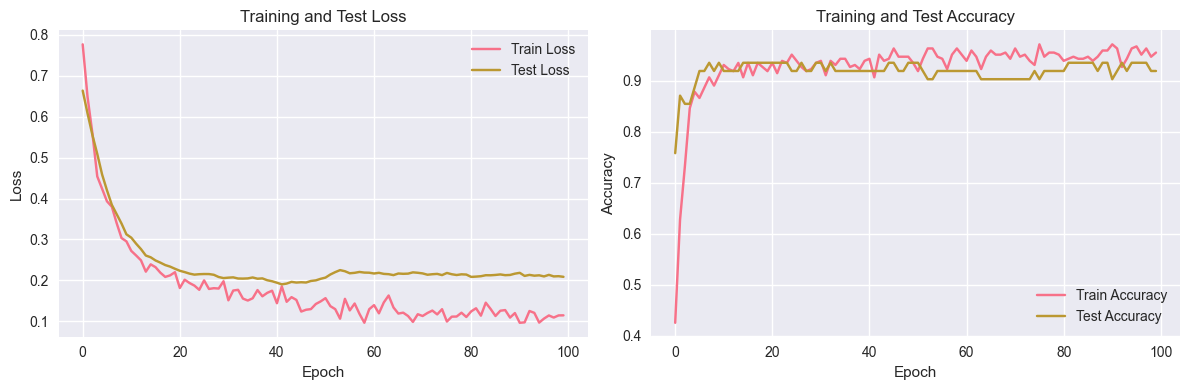

In [16]:
# Plot training history
plot_training_history(results['history'], save_path="../reports/training_history.png")


## Confusion Matrix Visualization


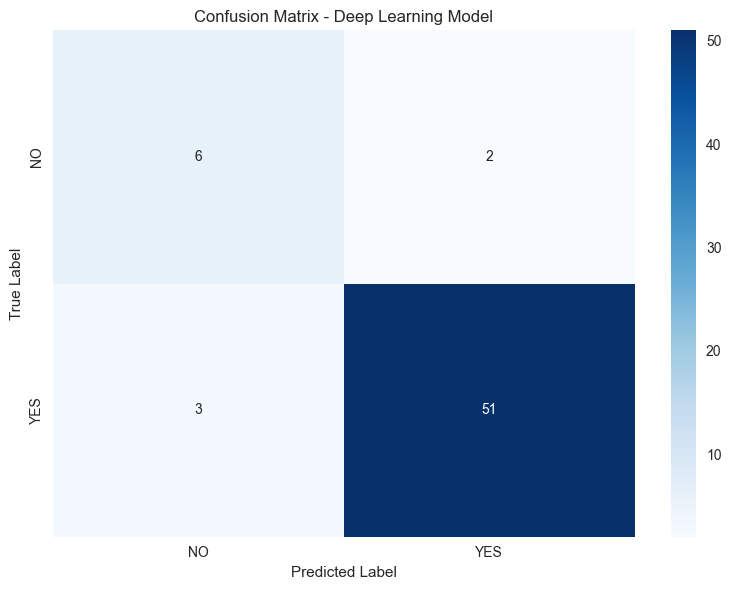

In [17]:
# Create confusion matrix
cm = confusion_matrix(results['y_true'], results['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.title('Confusion Matrix - Deep Learning Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## Model Comparison: Machine Learning vs Deep Learning


## Comprehensive Model Comparison

Now let's train and compare ALL deep learning architectures to find the best one for your thesis.


In [18]:
# Run comprehensive comparison of all models
# This will train all 18 architectures and create detailed reports
# Note: compare_all_models is already imported in Cell 11

results_df = compare_all_models(
    data_path="../data/raw/survey lung cancer.csv",
    num_epochs=100,
    batch_size=32,
    learning_rate=0.001,
    device=device,
    save_dir="../models",
    report_dir="../reports"
)

# Display results
display(results_df)


COMPREHENSIVE MODEL COMPARISON

[1/4] Loading and preprocessing data...
   Data loaded: 247 train, 62 test samples
   Input features: 15

[2/4] Training 17 models...

[1/17] Training: Standard (128-64-32)
   Description: Standard deep network with 3 hidden layers
   Parameters: 12,898
----------------------------------------------------------------------
Starting training...
Device: cpu
Model parameters: 12,898
--------------------------------------------------
Epoch [1/100]
  Train Loss: 0.8979, Train Acc: 0.2713
  Test Loss: 0.7261, Test Acc: 0.1774
--------------------------------------------------
Epoch [10/100]
  Train Loss: 0.3211, Train Acc: 0.8866
  Test Loss: 0.3705, Test Acc: 0.9032
--------------------------------------------------
Epoch [20/100]
  Train Loss: 0.1918, Train Acc: 0.9271
  Test Loss: 0.2509, Test Acc: 0.8871
--------------------------------------------------
Epoch [30/100]
  Train Loss: 0.1761, Train Acc: 0.9393
  Test Loss: 0.2100, Test Acc: 0.9032
----------

,Model,Description,Parameters,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Final Train Loss,Final Test Loss,Best Epoch
9,LayerNorm,Network with Layer Normalization,12898,0.951613,0.928817,0.903226,0.911042,0.953704,0.993628,0.107347,0.205859,25
3,Deep (5 layers),Very deep network with 5 hidden layers,18434,0.935484,0.944700,0.903226,0.913576,0.956019,0.993913,0.161878,0.172203,40
14,Deep (6 layers),Very deep network with 6 hidden layers,22722,0.935484,0.956989,0.935484,0.940695,0.956019,0.994127,0.207039,0.168508,36
5,ELU Activation,Standard architecture with ELU activation,12898,0.935484,0.914888,0.903226,0.907689,0.930556,0.989708,0.129152,0.266522,25
6,Minimal (32),Minimal network with few parameters,642,0.935484,0.915626,0.919355,0.917037,0.953704,0.993345,0.113427,0.203033,75
7,LeakyReLU,Network with LeakyReLU activation,12898,0.935484,0.924123,0.919355,0.921350,0.925926,0.988894,0.104273,0.243965,47
1,Simple (64-32),Simple 2-layer network,3362,0.935484,0.907193,0.887097,0.894397,0.918981,0.987555,0.085159,0.276962,25
11,Attention,Network with self-attention mechanism,93378,0.935484,0.914888,0.903226,0.907689,0.930556,0.989665,0.107812,0.266494,22
8,Swish Activation,Network with Swish activation function,12898,0.919355,0.907193,0.887097,0.894397,0.923611,0.988697,0.125250,0.293287,19
12,High Dropout (0.5),Network with high dropout for regularization,12898,0.919355,0.922672,0.887097,0.897797,0.946759,0.992622,0.174405,0.187567,11


## Visualize All Model Results


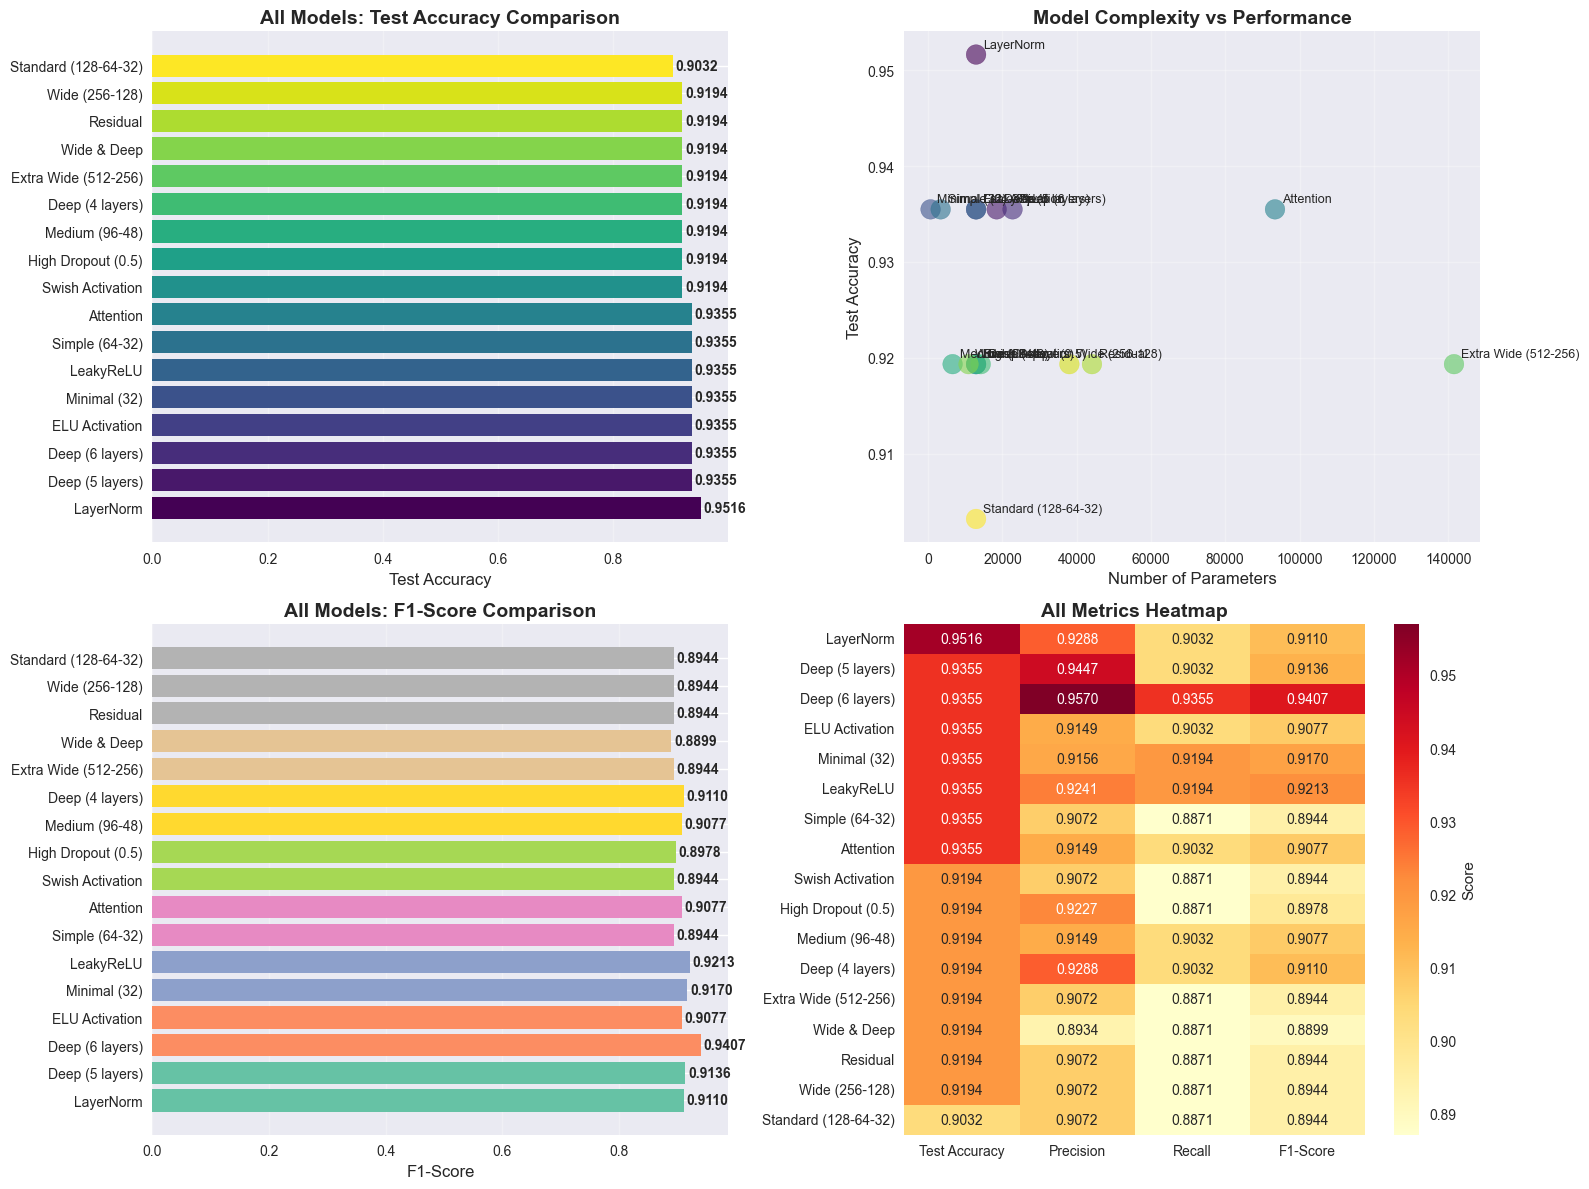


BEST MODEL SUMMARY
Best Model: LayerNorm
Test Accuracy: 0.9516
F1-Score: 0.9110
Parameters: 12,898


In [19]:
# Load the comparison results if they exist
import os
results_path = "../reports/model_comparison_results.csv"

if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    
    # Create a comprehensive comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Accuracy comparison
    ax1 = axes[0, 0]
    bars1 = ax1.barh(results_df['Model'], results_df['Test Accuracy'], 
                     color=plt.cm.viridis(np.linspace(0, 1, len(results_df))))
    ax1.set_xlabel('Test Accuracy', fontsize=12)
    ax1.set_title('All Models: Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    for bar, acc in zip(bars1, results_df['Test Accuracy']):
        ax1.text(acc + 0.005, bar.get_y() + bar.get_height()/2,
                f'{acc:.4f}', va='center', fontweight='bold')
    
    # 2. Parameters vs Accuracy
    ax2 = axes[0, 1]
    scatter = ax2.scatter(results_df['Parameters'], results_df['Test Accuracy'],
                         s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis')
    for i, row in results_df.iterrows():
        ax2.annotate(row['Model'], 
                    (row['Parameters'], row['Test Accuracy']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax2.set_xlabel('Number of Parameters', fontsize=12)
    ax2.set_ylabel('Test Accuracy', fontsize=12)
    ax2.set_title('Model Complexity vs Performance', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. F1-Score comparison
    ax3 = axes[1, 0]
    bars3 = ax3.barh(results_df['Model'], results_df['F1-Score'],
                     color=plt.cm.Set2(np.linspace(0, 1, len(results_df))))
    ax3.set_xlabel('F1-Score', fontsize=12)
    ax3.set_title('All Models: F1-Score Comparison', fontsize=14, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    for bar, f1 in zip(bars3, results_df['F1-Score']):
        ax3.text(f1 + 0.005, bar.get_y() + bar.get_height()/2,
                f'{f1:.4f}', va='center', fontweight='bold')
    
    # 4. All metrics heatmap
    ax4 = axes[1, 1]
    metrics_to_plot = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
    heatmap_data = results_df.set_index('Model')[metrics_to_plot]
    sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd', 
                ax=ax4, cbar_kws={'label': 'Score'})
    ax4.set_title('All Metrics Heatmap', fontsize=14, fontweight='bold')
    ax4.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('../reports/comprehensive_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("BEST MODEL SUMMARY")
    print("="*70)
    best_model = results_df.iloc[0]
    print(f"Best Model: {best_model['Model']}")
    print(f"Test Accuracy: {best_model['Test Accuracy']:.4f}")
    print(f"F1-Score: {best_model['F1-Score']:.4f}")
    print(f"Parameters: {best_model['Parameters']:,}")
    print("="*70)
else:
    print("Please run the model comparison first!")


Model Comparison:
                   Model  Accuracy             Type
Logistic Regression (ML)  0.903200 Machine Learning
Deep Neural Network (DL)  0.935484    Deep Learning


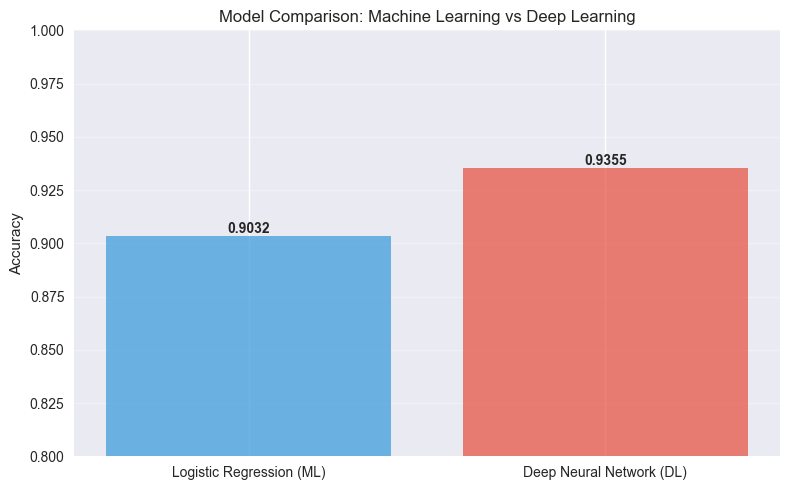

In [ ]:
## Comparison with Original Study

**Note:** Comparison with the original machine learning study will be added after discussion with supervisor.

For now, focus on the comprehensive deep learning model comparison above (Cell 26), which compares all 18 deep learning architectures.
